In [2]:
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from utils import get_classifier_metrics
from sklearn import tree
from sklearn.metrics import accuracy_score
import pickle

## Paso 3: Construir un modelo de árbol de decisión

### Árbol de Clasificación

In [3]:
X_train = pd.read_csv('/workspaces/inetke-machine-learning/data/processed/X_train_diabetes.csv')

X_train.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,1,124.0,60,32,0,35.8,0.514,21
1,12,151.0,70,40,271,41.8,0.742,38
2,1,153.0,82,42,485,40.6,0.687,23
3,7,106.0,92,18,0,22.7,0.235,48
4,12,121.0,78,17,0,26.5,0.259,62


In [19]:
X_test = pd.read_csv('/workspaces/inetke-machine-learning/data/processed/X_test_diabetes.csv')

X_test.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,0,100.0,88,60,110,46.8,0.962,31
1,4,148.0,60,27,318,30.9,0.150,29
2,1,189.0,60,23,846,30.1,0.398,59
3,0,118.0,84,47,230,45.8,0.551,31
4,1,125.0,50,40,167,33.3,0.962,28


In [20]:
y_train = pd.read_csv('/workspaces/inetke-machine-learning/data/processed/y_train_diabetes.csv')
y_train.head()

,Outcome
0,0
1,1
2,0
3,0
4,0


In [21]:
y_test = pd.read_csv('/workspaces/inetke-machine-learning/data/processed/y_test_diabetes.csv')
y_test.head()

,Outcome
0,0
1,1
2,1
3,1
4,1


In [7]:
classifier_model = DecisionTreeClassifier(random_state=18)
classifier_model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,18
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


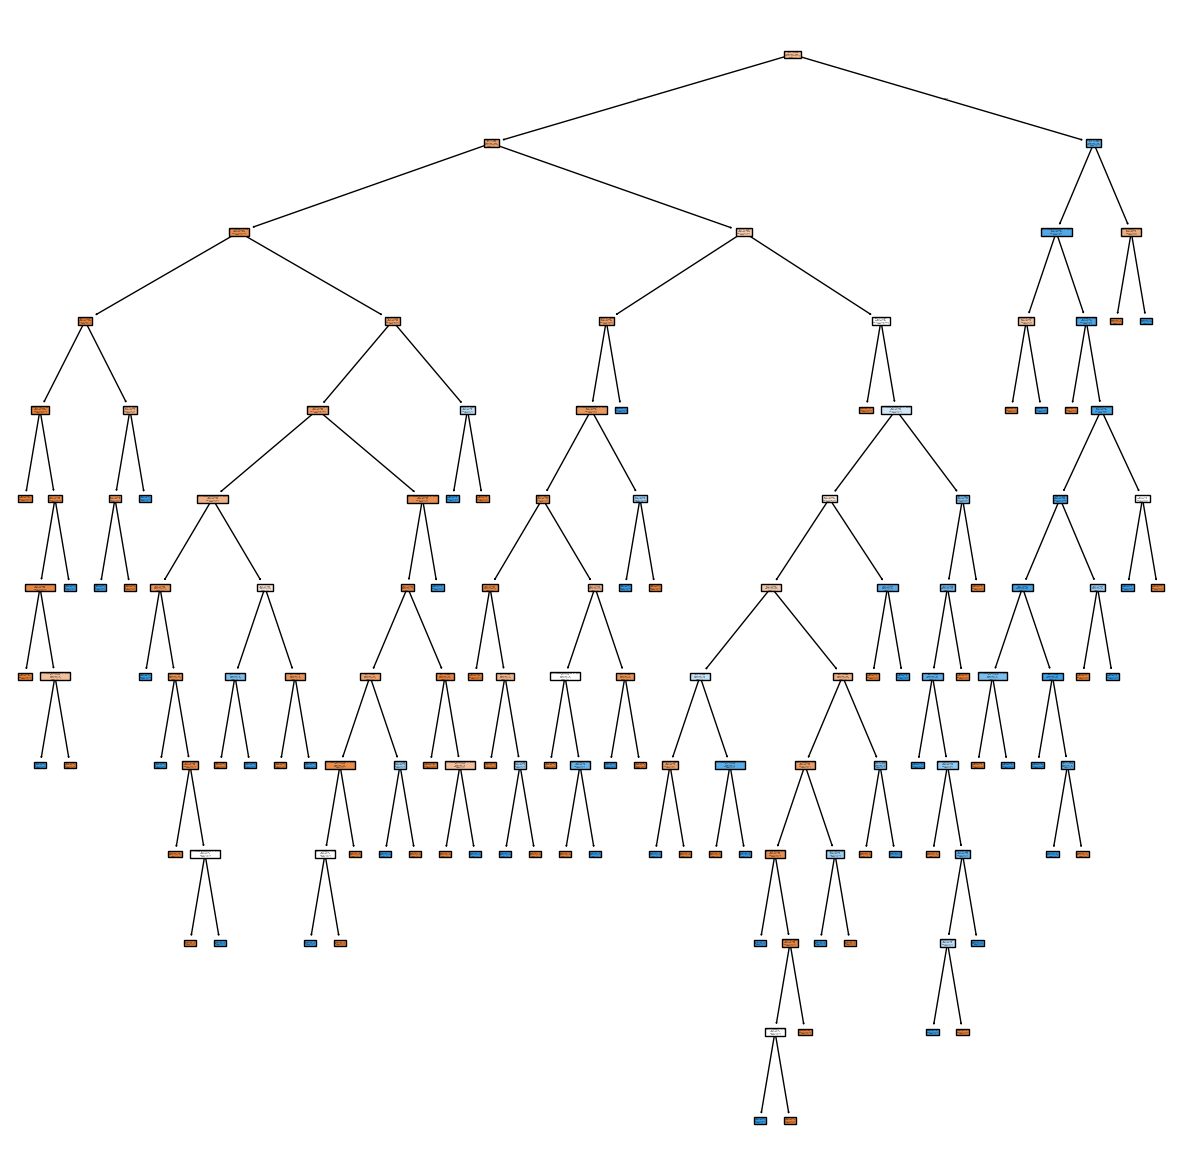

In [8]:
fig = plt.figure(figsize=(15,15))

tree.plot_tree(classifier_model,
               feature_names=list(X_train.columns),
               class_names=['0', '1'],
               filled=True)
plt.show()

#### Predicción

In [9]:
y_pred_test = classifier_model.predict(X_test)
y_pred_test

array([0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1,
       0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0,
       0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1,
       0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0])

In [10]:
y_pred_train = classifier_model.predict(X_train)
y_pred_train

array([0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0,
       0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1,
       1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1,
       0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1,
       0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0,
       1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1,
       0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0,
       1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0,
       0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0,
       1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1,
       1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0,

In [11]:
model_accurancy = accuracy_score(y_test, y_pred_test)

In [12]:
get_classifier_metrics(y_pred_test, y_test, y_pred_train, y_train)

,Accuracy,F1 Score,Precision,Recall
Train set,1.000000,1.000000,1.000000,1.000000
Test set,0.675926,0.675926,0.675926,0.675926


## Paso 4: Optimización del modelo

In [13]:
# We define the parameters we want to adjust manually.
hyperparams = {'criterion': ['gini', 'entropy'],
               'max_depth': [None, 5, 10, 15],
               'min_samples_split': [2, 5, 10],
               'min_samples_leaf': [1, 2, 4],
               'max_features': [None, 'sqrt', 'log2'],
               'ccp_alpha': [0.0, 1e-4, 1e-3]}

# We initialise the grid
grid = GridSearchCV(classifier_model,
                    hyperparams,
                    scoring="accuracy",
                    cv=5)
grid

,estimator,DecisionTreeC...ndom_state=18)
,param_grid,"{'ccp_alpha': [0.0, 0.0001, ...], 'criterion': ['gini', 'entropy'], 'max_depth': [None, 5, ...], 'max_features': [None, 'sqrt', ...], ...}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'gini'


In [14]:
grid.fit(X_train, y_train)

grid.best_params_

{'ccp_alpha': 0.0,
 'criterion': 'gini',
 'max_depth': 5,
 'max_features': 'log2',
 'min_samples_leaf': 4,
 'min_samples_split': 2}

Como vemos, los parámetros optimizados utilizando esta técnica son:

- `ccp_alpha`: 0.0
- `criterion`: gini
- `max_depth`: 5
- `max_features`: log2
- `min_samples_leaf`: 2
- `min_samples_split`: 5


In [15]:
grid.best_estimator_

,criterion,'gini'
,splitter,'best'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,4
,min_weight_fraction_leaf,0.0
,max_features,'log2'
,random_state,18
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


Utilizamos el conjunto de datos de entrenamiento para ajustarlo. Repetimos el entrenamiento estableciendo estos parámetros en el modelo:

In [16]:
best_model_grid = grid.best_estimator_

y_pred_grid = best_model_grid.predict(X_train)

grid_accuracy = accuracy_score(y_train, y_pred_grid)

model_accurancy, grid_accuracy

(0.6759259259259259, 0.8425925925925926)

In [17]:
grid_accuracy - model_accurancy

0.16666666666666663

El modelo final, un Árbol de Decisión optimizado mediante GridSearchCV, ha alcanzado una precisión (accuracy) de aproximadamente 0.84 en el conjunto de validación. Esto representa una mejora significativa respecto al modelo inicial no optimizado, que mostraba un claro sobreajuste con una precisión de 1.0 en entrenamiento y ~0.67 en test.

## Paso 5: Guardar el modelo

In [22]:
with open('/workspaces/inetke-machine-learning/models/decision-tree-diabetes.pkl', 'wb') as file:
    pickle.dump(classifier_model, file)